# **Importing libraries**

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchaudio
import torchaudio.transforms as T
import sys
import librosa
import torchvision
import numpy as np
from tqdm import tqdm
from torch.utils.data import Dataset
import random
import copy

import matplotlib.pyplot as plt
import IPython.display as ipd
import pandas as pd

%matplotlib inline

from torchsummary import summary
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import seaborn as sns

import glob


In [2]:
                                                        
                                                                                                                   
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)


def set_seed(seed: int = SEED, deterministic: bool = True):
    """Imposta i seed principali per rendere i run il più riproducibili possibile."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if deterministic:
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True
                                                                                                 
        torch.use_deterministic_algorithms(True, warn_only=True)


def seed_worker(worker_id):
    """Seed deterministico per eventuali worker del DataLoader."""
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)


set_seed(SEED)
generator = torch.Generator()
generator.manual_seed(SEED)

print(f"Seed impostato a {SEED}. Determinismo PyTorch attivo dove supportato.")


Seed impostato a 42. Determinismo PyTorch attivo dove supportato.


# Get Computtional Device

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# Importing the Dataset

In [4]:
# Ricerca automatica dei dataset dentro /kaggle/input
import re
KAGGLE_INPUT_ROOT = "/kaggle/input"


def _list_kaggle_input_folders(root=KAGGLE_INPUT_ROOT):
    """Restituisce una lista sintetica delle cartelle disponibili in /kaggle/input."""
    if not os.path.exists(root):
        return []
    return sorted([
        os.path.join(root, name)
        for name in os.listdir(root)
        if os.path.isdir(os.path.join(root, name))
    ])


def _find_dataset_root_by_filename(pattern, dataset_name, input_root=KAGGLE_INPUT_ROOT, required=True):
    """
    Cerca ricorsivamente dentro /kaggle/input i file .wav compatibili con un dataset
    e restituisce la cartella comune che li contiene.

    pattern: regex applicata al nome del file, non al path completo.
    """
    if not os.path.exists(input_root):
        if required:
            raise FileNotFoundError(
                f"Cartella {input_root} non trovata. Questa ricerca automatica è pensata per Kaggle."
            )
        return None

    regex = re.compile(pattern, re.IGNORECASE)
    matched_files = []

    for dirpath, _, filenames in os.walk(input_root):
        for filename in filenames:
            if filename.lower().endswith(".wav") and regex.fullmatch(filename):
                matched_files.append(os.path.join(dirpath, filename))

    if len(matched_files) == 0:
        available = _list_kaggle_input_folders(input_root)
        available_msg = "\n".join(f"  - {p}" for p in available[:20])
        message = (
            f"{dataset_name} non trovato automaticamente dentro {input_root}.\n"
            f"Cartelle disponibili:\n{available_msg if available_msg else '  Nessuna cartella trovata'}"
        )
        if required:
            raise FileNotFoundError(message)
        print("ATTENZIONE:", message)
        return None

    dataset_root = os.path.commonpath(matched_files)
    return dataset_root


def find_ravdess_path(input_root=KAGGLE_INPUT_ROOT):
    """
    Trova automaticamente RAVDESS cercando file con formato:
    03-01-EMO-INT-STAT-REP-ACTOR.wav
    """
    return _find_dataset_root_by_filename(
        pattern=r"03-01-\d{2}-\d{2}-\d{2}-\d{2}-\d{2}\.wav",
        dataset_name="RAVDESS",
        input_root=input_root,
        required=True
    )


def find_cremad_path(input_root=KAGGLE_INPUT_ROOT):
    """
    Trova automaticamente CREMA-D cercando file con formato:
    1001_DFA_ANG_XX.wav, 1001_DFA_HAP_XX.wav, ecc.
    """
    return _find_dataset_root_by_filename(
        pattern=r"\d+_[A-Z]+_(NEU|HAP|SAD|ANG|FEA|DIS)_[A-Z]+\.wav",
        dataset_name="CREMA-D",
        input_root=input_root,
        required=False
    )


DATASET_PATH = find_ravdess_path()
CREMAD_PATH = find_cremad_path()

emotion_map = {
    0: "neutral", 1: "calm", 2: "happy", 3: "sad",
    4: "angry", 5: "fearful", 6: "disgust", 7: "surprised"
}

cremad_emotion_map = {
    "NEU": 0,
    "HAP": 2,
    "SAD": 3,
    "ANG": 4,
    "FEA": 5,
    "DIS": 6,
}

USE_CREMAD = CREMAD_PATH is not None
MAX_CREMAD_PER_CLASS = None

USE_SEGMENTATION = True
SEGMENT_DURATION_SEC = 3.0
SEGMENT_HOP_SEC = 1.5
MIN_SEGMENT_DURATION_SEC = 1.0

print("RAVDESS path trovato automaticamente:", DATASET_PATH)
print("CREMA-D path trovato automaticamente:", CREMAD_PATH if CREMAD_PATH is not None else "non trovato")
print("Uso CREMA-D nel training:", USE_CREMAD and CREMAD_PATH is not None)
print("Uso segmentazione audio:", USE_SEGMENTATION)
print(f"Segmenti: {SEGMENT_DURATION_SEC}s, hop: {SEGMENT_HOP_SEC}s")


RAVDESS path trovato automaticamente: /kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio
CREMA-D path trovato automaticamente: /kaggle/input/datasets/ejlok1/cremad/AudioWAV
Uso CREMA-D nel training: True
Uso segmentazione audio: True
Segmenti: 3.0s, hop: 1.5s


# Data Agumentation

Implementare Time Stretching, Pitch Shifting, Compressione (DRC) e Iniezione di Rumore (BG) per migliorare la robustezza del modello e limitare l'overfitting.

In [5]:
def apply_time_stretch(wav, rate):
    return librosa.effects.time_stretch(y=wav, rate=rate)

def apply_pitch_shift(wav, sr, n_steps):
    return librosa.effects.pitch_shift(y=wav, sr=sr, n_steps=n_steps)

def add_white_noise(signal):
                                                                                           
    noise = np.random.normal(0, signal.std(), signal.shape)
    augmented_signal = signal + noise * 0.05
    return augmented_signal

def random_gain(signal, min_factor=0.1, max_factor=0.12):
                                                                    
                                                                                                     
    gain_rate = random.uniform(min_factor, max_factor)
    augmented_signal = signal * gain_rate
    return augmented_signal


In [6]:

class SpecAugment(nn.Module):
    """
    Applica SpecAugment a batch di log-mel spectrogram con shape (B, 1, freq, time).
    In questo notebook freq=64 e time=128 dopo il resize.
    Non fa transpose: FrequencyMasking lavora sull'asse frequenza e TimeMasking sull'asse tempo.
    """
    def __init__(self, freq_mask_param: int = 10, time_mask_param: int = 20,
                 n_time_masks: int = 1, iid_masks: bool = True):
        super().__init__()
        self.freq_masking = T.FrequencyMasking(freq_mask_param=freq_mask_param)
        self.time_maskings = nn.ModuleList([
            T.TimeMasking(time_mask_param=time_mask_param, iid_masks=iid_masks)
            for _ in range(n_time_masks)
        ])

    def forward(self, x: torch.Tensor) -> torch.Tensor:
                                                                
        x = self.freq_masking(x)
        for tm in self.time_maskings:
            x = tm(x)
        return x


spec_augment = SpecAugment(
    freq_mask_param=10,
    time_mask_param=20,
    n_time_masks=1,
    iid_masks=True
).to(device)

print('SpecAugment pronto:', spec_augment)


SpecAugment pronto: SpecAugment(
  (freq_masking): FrequencyMasking()
  (time_maskings): ModuleList(
    (0): TimeMasking()
  )
)


In [7]:
                                                               
                                                                                                   
import shutil

PROCESSED_ROOT = '/kaggle/working/processed_data'
if os.path.exists(PROCESSED_ROOT):
    shutil.rmtree(PROCESSED_ROOT)

os.makedirs(f'{PROCESSED_ROOT}/train', exist_ok=True)
os.makedirs(f'{PROCESSED_ROOT}/val', exist_ok=True)
os.makedirs(f'{PROCESSED_ROOT}/test', exist_ok=True)
print('Cartelle processed_data ricreate da zero.')


Cartelle processed_data ricreate da zero.


Crea il dataset aumentato + CREMA-D (cella da eseguire una sola volta)


In [8]:
def _load_audio_mono_16k(file_path, target_sr=16000):
    """Carica un file audio, lo converte in mono, lo ricampiona a 16 kHz, trimma il silenzio e normalizza."""
    waveform, sample_rate = torchaudio.load(file_path)
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    if sample_rate != target_sr:
        resampler = T.Resample(orig_freq=sample_rate, new_freq=target_sr)
        waveform = resampler(waveform)
        sample_rate = target_sr

    wav_np = waveform.squeeze().numpy()
    wav_trimmed, _ = librosa.effects.trim(wav_np, top_db=30)

                                                     
    if len(wav_trimmed) == 0:
        wav_trimmed = wav_np

    return librosa.util.normalize(wav_trimmed).astype(np.float32), sample_rate


def segment_audio(wav_data, sample_rate,
                  segment_duration_sec=SEGMENT_DURATION_SEC,
                  hop_sec=SEGMENT_HOP_SEC,
                  min_segment_duration_sec=MIN_SEGMENT_DURATION_SEC,
                  use_segmentation=USE_SEGMENTATION):
    """
    Divide un audio 1D in segmenti di durata fissa.
    - Se l'audio è più corto del segmento, fa padding a destra.
    - Se resta una coda troppo corta, la scarta.
    - Ritorna sempre almeno un segmento.
    """
    wav_data = np.asarray(wav_data, dtype=np.float32).reshape(-1)

    if not use_segmentation:
        return [librosa.util.normalize(wav_data).astype(np.float32)]

    segment_len = int(segment_duration_sec * sample_rate)
    hop_len = int(hop_sec * sample_rate)
    min_len = int(min_segment_duration_sec * sample_rate)

    if segment_len <= 0 or hop_len <= 0:
        raise ValueError("SEGMENT_DURATION_SEC e SEGMENT_HOP_SEC devono essere > 0")

    if len(wav_data) == 0:
        return [np.zeros(segment_len, dtype=np.float32)]

                                                                
    if len(wav_data) <= segment_len:
        padded = np.pad(wav_data, (0, segment_len - len(wav_data)), mode='constant')
        return [librosa.util.normalize(padded).astype(np.float32)]

    segments = []
    for start in range(0, len(wav_data), hop_len):
        end = start + segment_len
        segment = wav_data[start:end]

        if len(segment) < min_len:
            break

        if len(segment) < segment_len:
            segment = np.pad(segment, (0, segment_len - len(segment)), mode='constant')

        segments.append(librosa.util.normalize(segment).astype(np.float32))

        if end >= len(wav_data):
            break

    if len(segments) == 0:
        padded = np.pad(wav_data, (0, max(0, segment_len - len(wav_data))), mode='constant')[:segment_len]
        segments = [librosa.util.normalize(padded).astype(np.float32)]

    return segments


def _save_processed_sample(wav_data, sample_rate, emotion_label, speaker_id, subset_name, counters, source_name):
    """Salva un campione già preprocessato/segmentato nel formato atteso dal Dataset."""
    file_name = (
        f"{PROCESSED_ROOT}/{subset_name}/"
        f"sample_{counters[subset_name]}_{source_name}.pt"
    )
                                                                                     
    torch.save((np.asarray(wav_data, dtype=np.float32), sample_rate, int(emotion_label), int(speaker_id)), file_name)
    counters[subset_name] += 1


def _save_segments(wav_data, sample_rate, emotion_label, speaker_id, subset_name, counters, source_name):
    """Segmenta l'audio e salva ogni segmento come campione separato."""
    segments = segment_audio(wav_data, sample_rate)
    for seg_idx, segment in enumerate(segments):
        _save_processed_sample(
            wav_data=segment,
            sample_rate=sample_rate,
            emotion_label=emotion_label,
            speaker_id=speaker_id,
            subset_name=subset_name,
            counters=counters,
            source_name=f"{source_name}_seg{seg_idx:02d}"
        )
    return len(segments)


def _add_ravdess_files(root_dir, counters):
    """Aggiunge RAVDESS a train/val/test con split speaker-independent + segmentazione."""
    all_files = []
    for dirpath, _, filenames in os.walk(root_dir):
        for f in filenames:
            if f.endswith(".wav"):
                all_files.append(os.path.join(dirpath, f))

    ravdess_segments = {'train': 0, 'val': 0, 'test': 0}

    for file_path in tqdm(all_files, desc="RAVDESS -> processed_data"):
        filename = os.path.basename(file_path)
        parts = filename.replace(".wav", "").split("-")

        if len(parts) != 7:
            continue

        emotion_label = int(parts[2]) - 1
        speaker_id = int(parts[6])

        wav_orig, sample_rate = _load_audio_mono_16k(file_path)

        if speaker_id <= 18:
            subset = "train"
        elif 19 <= speaker_id <= 22:
            subset = "val"
        else:
            subset = "test"

                                                                 
        ravdess_segments[subset] += _save_segments(
            wav_orig, sample_rate, emotion_label, speaker_id, subset, counters, "ravdess"
        )

                                                                                        
        if subset == "train":
            for rate in [0.81, 0.93, 1.07, 1.23]:
                aug = apply_time_stretch(wav_orig, rate)
                ravdess_segments['train'] += _save_segments(aug, sample_rate, emotion_label, speaker_id, "train", counters, "ravdess_ts")

            for steps in [-3.5, -2.5, -2, -1, 1, 2, 2.5, 3.5]:
                aug = apply_pitch_shift(wav_orig, sample_rate, steps)
                ravdess_segments['train'] += _save_segments(aug, sample_rate, emotion_label, speaker_id, "train", counters, "ravdess_ps")

            for _ in range(2):
                aug = add_white_noise(wav_orig)
                ravdess_segments['train'] += _save_segments(aug, sample_rate, emotion_label, speaker_id, "train", counters, "ravdess_noise")

            for _ in range(2):
                aug = random_gain(wav_orig)
                ravdess_segments['train'] += _save_segments(aug, sample_rate, emotion_label, speaker_id, "train", counters, "ravdess_gain")

    print("\nSegmenti RAVDESS salvati:")
    for subset in ['train', 'val', 'test']:
        print(f"  {subset}: {ravdess_segments[subset]}")


def _find_cremad_wavs(cremad_root):
    """Trova i wav CREMA-D anche se il path Kaggle ha una struttura leggermente diversa."""
    candidate_roots = [cremad_root]
    if not os.path.exists(cremad_root):
        candidate_roots = [
            "/kaggle/input/cremad/AudioWAV",
            "/kaggle/input/crema-d/AudioWAV",
            "/kaggle/input/cremad",
            "/kaggle/input/crema-d",
            "/kaggle/input/crema-d-audio/AudioWAV",
        ]

    wav_files = []
    used_root = None
    for root in candidate_roots:
        if os.path.exists(root):
            wav_files = glob.glob(os.path.join(root, "**", "*.wav"), recursive=True)
            if len(wav_files) > 0:
                used_root = root
                break

    return wav_files, used_root


def _add_cremad_train_files(cremad_root, counters, max_per_class=None, seed=42):
    """Aggiunge CREMA-D SOLO al training set, con segmentazione, senza contaminare validation/test RAVDESS."""
    wav_files, used_root = _find_cremad_wavs(cremad_root)

    if len(wav_files) == 0:
        print("\nATTENZIONE: CREMA-D non trovato. Il notebook userà solo RAVDESS.")
        print("Controlla il path CREMAD_PATH o aggiungi il dataset CREMA-D su Kaggle.")
        return

    print(f"\nCREMA-D trovato in: {used_root}")
    print(f"File CREMA-D trovati: {len(wav_files)}")

    rng = random.Random(seed)
    rng.shuffle(wav_files)

    per_class_counter = {label: 0 for label in cremad_emotion_map.values()}
    per_class_segments = {label: 0 for label in cremad_emotion_map.values()}
    added_files = 0
    skipped = 0

    for file_path in tqdm(wav_files, desc="CREMA-D -> train"):
        filename = os.path.basename(file_path)
        parts = filename.replace(".wav", "").split("_")

                                             
        if len(parts) < 3:
            skipped += 1
            continue

        actor_id = parts[0]
        emotion_code = parts[2]

        if emotion_code not in cremad_emotion_map:
            skipped += 1
            continue

        emotion_label = cremad_emotion_map[emotion_code]

        if max_per_class is not None and per_class_counter[emotion_label] >= max_per_class:
            continue

        try:
            speaker_id = 10000 + int(actor_id)                                                  
            wav_orig, sample_rate = _load_audio_mono_16k(file_path)
            n_segments = _save_segments(wav_orig, sample_rate, emotion_label, speaker_id, "train", counters, "cremad")
            per_class_counter[emotion_label] += 1
            per_class_segments[emotion_label] += n_segments
            added_files += 1
        except Exception as e:
            skipped += 1
            print(f"Errore su {filename}: {e}")

    print(f"CREMA-D aggiunto al training: {added_files} file originali")
    print(f"CREMA-D saltati/non compatibili: {skipped} file")
    print("Distribuzione CREMA-D aggiunta per classe:")
    for label_id in sorted(per_class_counter):
        print(
            f"  {label_id} - {emotion_map[label_id]}: "
            f"{per_class_counter[label_id]} file -> {per_class_segments[label_id]} segmenti"
        )


def generate_augmented_dataset_ondisk(root_dir=DATASET_PATH, cremad_root=CREMAD_PATH, use_cremad=USE_CREMAD):
                                                                               
    set_seed(SEED)

    counters = {'train': 0, 'val': 0, 'test': 0}

    _add_ravdess_files(root_dir, counters)

    if use_cremad:
        _add_cremad_train_files(
            cremad_root=cremad_root,
            counters=counters,
            max_per_class=MAX_CREMAD_PER_CLASS,
            seed=SEED
        )

    print("\nSalvataggio completato con successo!")
    print(f"File/segmenti generati -> Train: {counters['train']}, Val: {counters['val']}, Test: {counters['test']}")
    print("Nota: validation e test restano solo RAVDESS speaker-independent; CREMA-D entra solo nel training.")


                    
generate_augmented_dataset_ondisk()


RAVDESS -> processed_data: 100%|██████████| 2880/2880 [06:57<00:00,  6.90it/s]



Segmenti RAVDESS salvati:
  train: 37524
  val: 498
  test: 248

CREMA-D trovato in: /kaggle/input/datasets/ejlok1/cremad/AudioWAV
File CREMA-D trovati: 7442


CREMA-D -> train: 100%|██████████| 7442/7442 [02:16<00:00, 54.61it/s]

CREMA-D aggiunto al training: 7442 file originali
CREMA-D saltati/non compatibili: 0 file
Distribuzione CREMA-D aggiunta per classe:
  0 - neutral: 1087 file -> 1188 segmenti
  2 - happy: 1271 file -> 1351 segmenti
  3 - sad: 1271 file -> 1507 segmenti
  4 - angry: 1271 file -> 1361 segmenti
  5 - fearful: 1271 file -> 1430 segmenti
  6 - disgust: 1271 file -> 1655 segmenti

Salvataggio completato con successo!
File/segmenti generati -> Train: 46016, Val: 498, Test: 248
Nota: validation e test restano solo RAVDESS speaker-independent; CREMA-D entra solo nel training.


Dataset per il training con RAVDESS + CREMA-D


In [9]:
class FastSpeechEmotionDataset(Dataset):
    def __init__(self, folder_path):
        """
        Cerca tutti i file .pt generati nella cartella specifica.
        Funziona sia con campioni RAVDESS sia con campioni CREMA-D già preprocessati/segmentati.
        """
        self.file_paths = sorted(glob.glob(f"{folder_path}/*.pt"))

    def __len__(self):
        return len(self.file_paths)

    @staticmethod
    def _unpack_saved_sample(sample):
        """
        Compatibilità con file .pt salvati in formati diversi:
        - nuovo formato: (wav_np, sample_rate, emotion_label, speaker_id)
        - eventuale vecchio formato: (wav_np, sample_rate, emotion_label, speaker_id, ...)
        """
        if not isinstance(sample, (tuple, list)) or len(sample) < 4:
            raise ValueError(f"Formato sample non valido: attesi almeno 4 elementi, trovati {type(sample)}")
        wav_np, sample_rate, emotion_label, speaker_id = sample[:4]
        return wav_np, sample_rate, emotion_label, speaker_id

    def __getitem__(self, idx):
        file_to_load = self.file_paths[idx]
        sample = torch.load(file_to_load, weights_only=False)
        wav_np, sample_rate, emotion_label, speaker_id = self._unpack_saved_sample(sample)

        wav_np = np.asarray(wav_np, dtype=np.float32).reshape(-1)
        wav_norm = librosa.util.normalize(wav_np)
        waveform = torch.tensor(wav_norm, dtype=torch.float32).unsqueeze(0)

        if sample_rate != 16000:
            resampler = T.Resample(orig_freq=sample_rate, new_freq=16000)
            waveform = resampler(waveform)
            sample_rate = 16000

        label_tensor = torch.tensor(int(emotion_label), dtype=torch.long)
        return waveform, sample_rate, label_tensor, int(speaker_id), 0


                                                                                 
FastRavdessDataset = FastSpeechEmotionDataset


DataLoader

In [10]:
                                                                
train_dataset = FastSpeechEmotionDataset('/kaggle/working/processed_data/train')
val_dataset   = FastSpeechEmotionDataset('/kaggle/working/processed_data/val')
test_dataset  = FastSpeechEmotionDataset('/kaggle/working/processed_data/test')

print(f"Campioni/segmenti di training pronti: {len(train_dataset)}")
print(f"Campioni/segmenti di validation pronti: {len(val_dataset)}")
print(f"Campioni/segmenti di test pronti: {len(test_dataset)}")

                                                                             
from collections import Counter

def count_labels(dataset):
    labels = []
    for fp in dataset.file_paths:
        sample = torch.load(fp, weights_only=False)
        _, _, emotion_label, _ = FastSpeechEmotionDataset._unpack_saved_sample(sample)
        labels.append(int(emotion_label))
    return Counter(labels)

train_counts = count_labels(train_dataset)
val_counts = count_labels(val_dataset)
test_counts = count_labels(test_dataset)

print("\nDistribuzione classi TRAIN:")
for i in range(8):
    print(f"  {i} - {emotion_map[i]:10s}: {train_counts.get(i, 0)}")

print("\nDistribuzione classi VALIDATION:")
for i in range(8):
    print(f"  {i} - {emotion_map[i]:10s}: {val_counts.get(i, 0)}")

print("\nDistribuzione classi TEST:")
for i in range(8):
    print(f"  {i} - {emotion_map[i]:10s}: {test_counts.get(i, 0)}")


Campioni/segmenti di training pronti: 46016
Campioni/segmenti di validation pronti: 498
Campioni/segmenti di test pronti: 248

Distribuzione classi TRAIN:
  0 - neutral   : 3638
  1 - calm      : 5102
  2 - happy     : 6293
  3 - sad       : 6543
  4 - angry     : 6319
  5 - fearful   : 6446
  6 - disgust   : 6773
  7 - surprised : 4902

Distribuzione classi VALIDATION:
  0 - neutral   : 32
  1 - calm      : 64
  2 - happy     : 66
  3 - sad       : 66
  4 - angry     : 64
  5 - fearful   : 66
  6 - disgust   : 76
  7 - surprised : 64

Distribuzione classi TEST:
  0 - neutral   : 16
  1 - calm      : 32
  2 - happy     : 32
  3 - sad       : 38
  4 - angry     : 34
  5 - fearful   : 32
  6 - disgust   : 32
  7 - surprised : 32


# Verifica Visiva della Data Augmentation

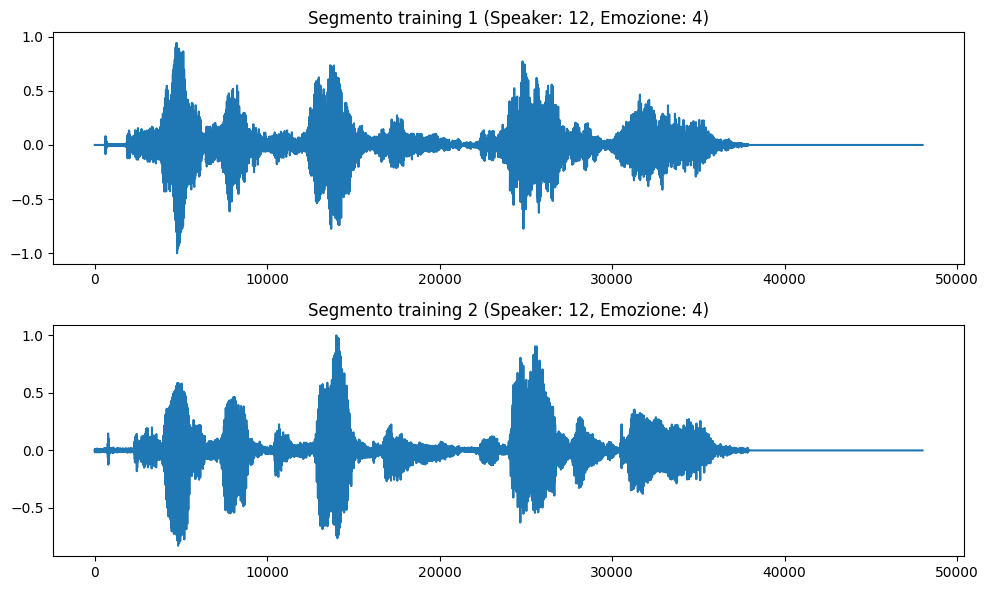

In [11]:
import matplotlib.pyplot as plt

                                                           
if len(train_dataset) < 2:
    raise RuntimeError("Il training set contiene meno di 2 campioni: controlla la generazione dei dati.")

idx = min(3, len(train_dataset) - 2)
idx_2 = min(idx + 1, len(train_dataset) - 1)

waveform, sample_rate, label, speaker_id, _ = train_dataset[idx]
waveform_2, _, label_2, speaker_id_2, _ = train_dataset[idx_2]

fig, axs = plt.subplots(2, 1, figsize=(10, 6))

axs[0].plot(waveform[0].numpy())
axs[0].set_title(f"Segmento training 1 (Speaker: {speaker_id}, Emozione: {label.item()})")

axs[1].plot(waveform_2[0].numpy())
axs[1].set_title(f"Segmento training 2 (Speaker: {speaker_id_2}, Emozione: {label_2.item()})")

plt.tight_layout()
plt.show()


In [12]:
print(f" Speaker {speaker_id} saying '{label}'")
print()
                                                             
ipd.display(ipd.Audio(waveform.numpy(), rate=sample_rate))

 Speaker 12 saying '4'



Run the following cell and listen to the sample

In [13]:
import torchaudio.transforms as T
import torchvision

n_fft = 512
win_length = 400
hop_length = 160
n_mels = 128                                             
resample_freq = 16000

specgramFn = T.Spectrogram(n_fft=n_fft, win_length=win_length, hop_length=hop_length, power=2.0)
melscaleFn = T.MelScale(n_mels=n_mels, sample_rate=resample_freq, n_stft=n_fft//2+1)
amplitude_to_db_transform = T.AmplitudeToDB(stype='power', top_db=80)

                                                                        
                                                                              
_resizeFn = torchvision.transforms.Resize((128, 128))


/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (257) may be set too low.
  warnings.warn(


In [14]:
def pad_sequence(batch):
                                                             
                                            
    batch = [item.t() for item in batch]
    batch = torch.nn.utils.rnn.pad_sequence(batch, batch_first=True, padding_value=0.)
    return batch.permute(0, 2, 1)


def collate_fn(batch):
    tensors, targets = [], []

    for data in batch:
        waveform = data[0]
        label = data[2]
                                                                                        
        tensors.append(waveform) 
        
                                          
        targets.append(label)

    padded_waveforms = pad_sequence(tensors)
    
    spec_tensors = specgramFn(padded_waveforms)
    melspec_tensors = melscaleFn(spec_tensors)
    db_melspec_tensors = amplitude_to_db_transform(melspec_tensors)
    
                                                   
                                                                   
    mel = _resizeFn(db_melspec_tensors)
   
    targets = torch.stack(targets)

    return mel, targets

batch_size = 64 

if device.type == "cuda":
    num_workers = 4
    pin_memory = True
else:
    num_workers = 0
    pin_memory = False

                                                                   
generator.manual_seed(SEED)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn, 
    num_workers=num_workers,
    pin_memory=pin_memory,
    generator=generator,
    worker_init_fn=seed_worker,
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False,
    collate_fn=collate_fn,
    num_workers=num_workers,
    pin_memory=pin_memory,
    worker_init_fn=seed_worker,
)
val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False,
    collate_fn=collate_fn,
    num_workers=num_workers,
    pin_memory=pin_memory,
    worker_init_fn=seed_worker,
)

# Funzioni generiche per training e valutazione

La funzione di training applica il modello ai batch del training set, calcola la loss, esegue backpropagation e aggiorna i pesi.

La funzione riceve:
* una eventuale trasformazione aggiuntiva sui dati, oppure `None`;
* la funzione di loss (`criterion`);
* l'ottimizzatore;
* opzionalmente lo scheduler.

In questo notebook SpecAugment viene applicato solo durante il training, mentre validation e test restano non aumentati per misurare la generalizzazione reale.


In [15]:

def train(model, transform, criterion, optimizer, epoch, log_interval, scheduler=None):
    """
    Esegue una epoca di training.
    Nota: lo scheduler NON viene aggiornato qui; viene aggiornato una sola volta per epoca
    nella cella principale di training.
    """
    model.train()
    running_loss = 0.0

    batch_iterator = tqdm(train_loader, desc=f"Train epoch {epoch}", leave=False)

    for batch_idx, (data, target) in enumerate(batch_iterator):
        data, target = data.to(device), target.to(device)

                                                   
        data = spec_augment(data)

        if transform is not None:
            data = data.contiguous()
            data = transform(data)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        batch_iterator.set_postfix(loss=f"{loss.item():.4f}")

        if batch_idx % log_interval == 0:
            print(
                f"  Train Epoch: {epoch} "
                f"[{batch_idx * len(data)}/{len(train_loader.dataset)} "
                f"({100. * batch_idx / len(train_loader):.0f}%)]  "
                f"Loss: {loss.item():.6f}"
            )

    return running_loss / len(train_loader)


# Valutazione del modello

Durante la valutazione il modello viene messo in modalità `eval()`. Questo è necessario perché livelli come Dropout e Batch Normalization si comportano diversamente tra training e inference.

La valutazione finale viene fatta in due modi:
* **segment-level**, cioè ogni segmento audio è classificato separatamente;
* **utterance-level**, cioè i segmenti provenienti dalla stessa frase/audio originale vengono aggregati per ottenere una sola predizione finale.


Definizione delle funzioni di valutazione: summary train/validation/test, metriche segment-level e metriche utterance-level.


In [16]:
import os
import re

def evaluate(model, loader, criterion, split='Val'):
    model.eval()
    total_loss, correct = 0.0, 0

    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)

            output = model(data)
            total_loss += criterion(output, target).item()
            correct += output.argmax(dim=-1).eq(target).sum().item()

    avg_loss = total_loss / len(loader)
    accuracy = 100. * correct / len(loader.dataset)
    error = 100. - accuracy

    print(
        f'  [{split}] Loss: {avg_loss:.4f}  '
        f'Accuracy: {correct}/{len(loader.dataset)} ({accuracy:.2f}%)  '
        f'Error: {error:.2f}%'
    )

    return accuracy, avg_loss


def compute_split_metrics(model, loader, criterion, device, transform=None):
    """Calcola loss, accuracy ed error su uno split, senza confusion matrix."""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in loader:
            data = data.to(device)
            target = target.to(device)

            if transform is not None:
                data = data.contiguous()
                data = transform(data)

            output = model(data)
            total_loss += criterion(output, target).item()
            preds = output.argmax(dim=-1)
            correct += preds.eq(target).sum().item()
            total += target.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = 100.0 * correct / total
    error = 100.0 - accuracy
    return avg_loss, accuracy, error


def print_error_summary(model, criterion, device, transform=None):
    """Stampa Training/Validation/Test loss, accuracy ed error per bias/variance."""
    train_loss, train_acc, train_error = compute_split_metrics(model, train_loader, criterion, device, transform)
    val_loss, val_acc, val_error = compute_split_metrics(model, val_loader, criterion, device, transform)
    test_loss, test_acc, test_error = compute_split_metrics(model, test_loader, criterion, device, transform)

    print("\n" + "="*60)
    print("SUMMARY FINALE: ACCURACY ED ERROR")
    print("="*60)
    print(f"Train      | Loss: {train_loss:.4f} | Acc: {train_acc:.2f}% | Error: {train_error:.2f}%")
    print(f"Validation | Loss: {val_loss:.4f} | Acc: {val_acc:.2f}% | Error: {val_error:.2f}%")
    print(f"Test       | Loss: {test_loss:.4f} | Acc: {test_acc:.2f}% | Error: {test_error:.2f}%")
    print("-"*60)
    print(f"Variance gap (Validation error - Training error): {val_error - train_error:.2f}%")
    print(f"Test gap (Test error - Training error): {test_error - train_error:.2f}%")
    print("="*60)

    return {
        'train_loss': train_loss, 'train_acc': train_acc, 'train_error': train_error,
        'val_loss': val_loss, 'val_acc': val_acc, 'val_error': val_error,
        'test_loss': test_loss, 'test_acc': test_acc, 'test_error': test_error,
        'variance_gap': val_error - train_error
    }


def evaluate_model(model, loader, device, transform=None, classes=None, split_name='Test'):
    """Valutazione finale con accuracy, error, F1 macro e confusion matrix."""
    model.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for data, target in loader:
            data = data.to(device)
            target = target.to(device)

            if transform is not None:
                data = data.contiguous()
                data = transform(data)

            output = model(data)
            preds = output.argmax(dim=-1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(target.cpu().numpy())

    acc = accuracy_score(all_targets, all_preds)
    error = 1.0 - acc
    f1 = f1_score(all_targets, all_preds, average='macro')
    cm = confusion_matrix(all_targets, all_preds)

    print("\n" + "="*45)
    print(f"RISULTATI FINALI SUL {split_name.upper()} SET")
    print("="*45)
    print(f"Accuracy Generale: {acc * 100:.2f}%")
    print(f"Error Rate: {error * 100:.2f}%")
    print(f"F1-Score (Macro): {f1:.4f}")

    if classes is None:
        classes = [emotion_map[i] for i in range(len(cm))]

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=classes,
        yticklabels=classes
    )
    plt.xlabel('Predizione del Modello')
    plt.ylabel('Emozione Reale')
    plt.title(f'Matrice di Confusione - {split_name}')
    plt.tight_layout()
    plt.show()

    return acc, f1, cm



def _segment_file_number(file_path):
    """Estrae il contatore numerico da sample_<id>_...pt per ordinare i segmenti correttamente."""
    match = re.search(r"sample_(\d+)_", os.path.basename(file_path))
    return int(match.group(1)) if match else -1


def _segment_index_from_name(file_path):
    """Estrae segXX dal nome del file. Se manca, considera il campione come segmento unico."""
    match = re.search(r"_seg(\d+)\.pt$", os.path.basename(file_path))
    return int(match.group(1)) if match else 0


def _utterance_groups_from_dataset(dataset):
    """
    Ricostruisce i gruppi utterance a partire dai segmenti salvati su disco.
    Durante la generazione, i segmenti dello stesso audio sono salvati consecutivamente
    e il nome termina con _seg00, _seg01, ... .
    """
    ordered_paths = sorted(dataset.file_paths, key=_segment_file_number)

    groups = []
    current_group = []

    for file_path in ordered_paths:
        seg_idx = _segment_index_from_name(file_path)

                                                                                            
        if seg_idx == 0 and current_group:
            groups.append(current_group)
            current_group = []

        current_group.append(file_path)

    if current_group:
        groups.append(current_group)

    return groups


def evaluate_utterance_level(model, dataset, device, classes=None, split_name='Test'):
    """
    Valutazione utterance-level.
    Ogni segmento viene classificato dal modello; poi le probabilità softmax dei segmenti
    appartenenti alla stessa utterance vengono mediate per ottenere una sola predizione finale.
    """
    model.eval()

    utterance_groups = _utterance_groups_from_dataset(dataset)
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for group_paths in utterance_groups:
            waveforms = []
            targets = []

            for file_path in group_paths:
                sample = torch.load(file_path, weights_only=False)
                wav_np, sample_rate, emotion_label, speaker_id = FastSpeechEmotionDataset._unpack_saved_sample(sample)

                wav_np = np.asarray(wav_np, dtype=np.float32).reshape(-1)
                wav_norm = librosa.util.normalize(wav_np)
                waveform = torch.tensor(wav_norm, dtype=torch.float32).unsqueeze(0)

                if sample_rate != 16000:
                    resampler = T.Resample(orig_freq=sample_rate, new_freq=16000)
                    waveform = resampler(waveform)

                waveforms.append(waveform)
                targets.append(int(emotion_label))

            if len(set(targets)) != 1:
                raise ValueError(
                    "Trovati segmenti con label diverse nella stessa utterance. "
                    "Controlla la generazione dei file segmentati."
                )

            padded_waveforms = pad_sequence(waveforms)
            spec_tensors = specgramFn(padded_waveforms)
            melspec_tensors = melscaleFn(spec_tensors)
            db_melspec_tensors = amplitude_to_db_transform(melspec_tensors)
            mel = _resizeFn(db_melspec_tensors).to(device)

            output = model(mel)
            probs = torch.softmax(output, dim=-1)
            mean_probs = probs.mean(dim=0)
            pred = int(mean_probs.argmax().cpu().item())

            all_preds.append(pred)
            all_targets.append(targets[0])

    acc = accuracy_score(all_targets, all_preds)
    error = 1.0 - acc
    f1 = f1_score(all_targets, all_preds, average='macro')
    cm = confusion_matrix(all_targets, all_preds)

    print("\n" + "="*55)
    print(f"RISULTATI FINALI UTTERANCE-LEVEL SUL {split_name.upper()} SET")
    print("="*55)
    print(f"Numero utterance valutate: {len(all_targets)}")
    print(f"Accuracy Generale: {acc * 100:.2f}%")
    print(f"Error Rate: {error * 100:.2f}%")
    print(f"F1-Score (Macro): {f1:.4f}")

    if classes is None:
        classes = [emotion_map[i] for i in range(len(cm))]

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=classes,
        yticklabels=classes
    )
    plt.xlabel('Predizione del Modello')
    plt.ylabel('Emozione Reale')
    plt.title(f'Matrice di Confusione Utterance-Level - {split_name}')
    plt.tight_layout()
    plt.show()

    return acc, f1, cm


## Mel spectrogram model (with 2D transformation)
**Task: Mel Spectrogram Transform.** Starting from the data visualization section where the Mel Spectrogram of a sample has been computed, build _transform pipeline_ to convert the audio samples to the Mel spectrogram representation.

* H: check the shape of the 2D array before using it as input to the model, i.e. the number of bins (values) both in the time and frequency domain.



La forma del tensore usato dalla CRNN è:

$$\text{Shape} = (\text{Canali}, \text{Frequenza}, \text{Tempo})$$

Nel notebook il mel-spectrogram viene prima calcolato con `n_mels = 128`, poi viene ridimensionato a una dimensione fissa tramite:

```python
_resizeFn = torchvision.transforms.Resize((64, 128))   (non più)
```

Quindi il modello non riceve direttamente una matrice `128 × T`, ma un tensore finale di forma:

$$1 \times 64 \times 128$$

Dove:

1. **Canali**: vale 1, perché il segnale audio è convertito in mono.
2. **Asse della frequenza**: dopo il resize vale 64. Le 128 bande Mel iniziali vengono compresse/ridimensionate a 64 per avere una rappresentazione più compatta.
3. **Asse del tempo**: dopo il resize vale 128 frame temporali. Questo rende tutti i segmenti confrontabili anche se la durata effettiva produce un numero di frame leggermente diverso.

Questa scelta mantiene una rappresentazione tempo-frequenza stabile per la CNN/GRU senza modificare i parametri audio principali (`n_fft`, `win_length`, `hop_length`, `n_mels`).


Per i modelli di Deep Learning, il tensore bidimensionale (128 Bande Mel $\times$ X Frame) è l'input principale.

# Network Model

In [17]:

class CRNN(nn.Module):
    """
    CRNN Architecture (Choi et al., 2016):
    - 4x Conv2D (3x3 kernel) + BatchNorm + ELU + MaxPool + Dropout(0.1)
    - AdaptiveAvgPool2d -> (freq=1, time=15)
    - 2-layer GRU
    - Last hidden state -> FC -> num_classes
    
    Input: (batch, 1, 64, 128)  [log-mel spectrogram dopo resize]
    Output: (batch, num_classes) [logit scores]
    """

    def __init__(self, num_classes: int, n_channels: int = 68,
                 rnn_hidden: int = 68, rnn_layers: int = 2,
                 dropout: float = 0.3):
        super().__init__()

                                                                            
                                                                           
                                                                            
                                                               
         
                                                                 
                                            
                                            
                                            
                                                                         

        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1,              n_channels,   kernel_size=3, padding=1),
            nn.BatchNorm2d(n_channels),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=(2, 2)),                               
            nn.Dropout(dropout),
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(n_channels,   n_channels*2, kernel_size=3, padding=1),
            nn.BatchNorm2d(n_channels * 2),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=(2, 2)),                               
            nn.Dropout(dropout),
        )
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(n_channels*2, n_channels*2, kernel_size=3, padding=1),
            nn.BatchNorm2d(n_channels * 2),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=(4, 2)),                               
            nn.Dropout(dropout),
        )
        self.conv_block4 = nn.Sequential(
            nn.Conv2d(n_channels*2, n_channels*2, kernel_size=3, padding=1),
            nn.BatchNorm2d(n_channels * 2),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=(4, 2)),                               
            nn.Dropout(dropout),
        )

                                                                              
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 8))
                                                                              
                                                 
                                                                         
                                     
        self.rnn = nn.GRU(
            input_size=n_channels * 2,
            hidden_size=rnn_hidden,
            num_layers=rnn_layers,
            batch_first=True,
            dropout=dropout if rnn_layers > 1 else 0.0,
        )

                                                                            
                                                 
                                                                      
        self.fc = nn.Linear(rnn_hidden, num_classes)
     
    def forward(self, x):
                                                                    

                                                           
        x = self.conv_block1(x)                          
        x = self.conv_block2(x)                          
        x = self.conv_block3(x)                          
        x = self.conv_block4(x)                          

                                                                
        x = self.adaptive_pool(x)                        
        x = x.squeeze(2)                             

                                                        
        x = x.permute(0, 2, 1)                    

                                        
                                                
        _, h_n = self.rnn(x)
        x = h_n[-1]                                                     

                                   
        return self.fc(x)                            


                                                        
NUMERO_EMOZIONI = 8

                                                                                  
set_seed(SEED)

model_crnn = CRNN(
    num_classes=NUMERO_EMOZIONI,
    n_channels=96,      #MODIFICATO (era 68)                                                    
    rnn_hidden=128,     #MODIFICATO (era 68)                                                     
    rnn_layers=2,                                                       
    dropout=0.25        #MODIFICATO (era 0.3)                                          
)
                                                                                
_dummy = torch.zeros(2, 1, 64, 128)
with torch.no_grad():
    _out = model_crnn(_dummy)
print(f"Shape check  →  input: {list(_dummy.shape)}   output: {list(_out.shape)}")
assert _out.shape == (2, NUMERO_EMOZIONI), "Shape mismatch!"
print("✅ Forward pass OK\n")

total_params = sum(p.numel() for p in model_crnn.parameters() if p.requires_grad)
print(f"Variante:          0.5M  (n_channels=68, rnn_hidden=68)")
print(f"Parametri totali:  {total_params:,}")
print()
print(model_crnn)

Shape check  →  input: [2, 1, 64, 128]   output: [2, 8]
✅ Forward pass OK

Variante:          0.5M  (n_channels=68, rnn_hidden=68)
Parametri totali:  1,056,072

CRNN(
  (conv_block1): Sequential(
    (0): Conv2d(1, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ELU(alpha=1.0)
    (3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.25, inplace=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(96, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ELU(alpha=1.0)
    (3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.25, inplace=False)
  )
  (conv_block3): Sequential(
    (0): Conv2d(192, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNo

In [18]:
BEST_MODEL_PATH = '/kaggle/working/best_crnn_model_cremad_reg_fix.pth'

                                                                                
epochs        = 50
log_interval  = 10
learning_rate = 0.0005

                
patience           = 7
min_delta          = 1e-4
early_stop_counter = 0

best_val_loss = np.inf
best_val_acc_at_best_loss = 0.0
max_val_acc = 0.0
max_val_acc_epoch = 0
best_state    = None
best_epoch    = 0

model = model_crnn.to(device)

                                                                                          
                                                 
train_label_counts = count_labels(train_dataset)
class_counts = torch.tensor([train_label_counts.get(i, 0) for i in range(8)], dtype=torch.float32)
class_weights = class_counts.sum() / (len(class_counts) * class_counts.clamp(min=1.0))
class_weights = class_weights.to(device)
print("Class weights:", {emotion_map[i]: round(class_weights[i].item(), 3) for i in range(8)})

                                                   
                                                          
criterion = nn.CrossEntropyLoss(
    weight=class_weights,                                     
    label_smoothing=0.1                                
)

                                                  
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=3e-4)

                                                                            
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6
)

                                                                                             
set_seed(SEED)
generator.manual_seed(SEED)

history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

print(f"Inizio Addestramento su dispositivo: {device}")
print("=" * 40)

for epoch in range(1, epochs + 1):
    print(f"\nEpoch {epoch}/{epochs}")

    train_loss = train(
        model, transform=None, criterion=criterion,
        optimizer=optimizer, epoch=epoch, log_interval=log_interval,
        scheduler=None                                                            
    )

    val_acc, val_loss = evaluate(model, val_loader, criterion, split='Val')

                                                                            
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

                                                                    
    if val_acc > max_val_acc:
        max_val_acc = val_acc
        max_val_acc_epoch = epoch

                                               
    if val_loss < best_val_loss - min_delta:
        best_val_loss = val_loss
        best_val_acc_at_best_loss = val_acc
        best_state    = copy.deepcopy(model.state_dict())
        best_epoch    = epoch
        early_stop_counter = 0

        torch.save(best_state, BEST_MODEL_PATH)
        print(
            f"  Nuovo best model salvato su disco "
            f"(epoch {epoch}, val_loss={val_loss:.4f}, val_acc_at_best_loss={val_acc:.1f}%)"
        )
    else:
        early_stop_counter += 1
        print(f"  Nessun miglioramento della val_loss ({early_stop_counter}/{patience})")

    if early_stop_counter >= patience:
        print(f"\nEarly stopping attivato alla epoch {epoch}.")
        break

print(
    f"\nTraining completato. "
    f"Best epoch: {best_epoch}, "
    f"Best val loss: {best_val_loss:.4f}, "
    f"Val acc at best loss: {best_val_acc_at_best_loss:.1f}%, "
    f"Max val acc: {max_val_acc:.1f}% at epoch {max_val_acc_epoch}"
)

                                                         
if best_state is None:
    raise RuntimeError("Nessun best_state salvato: controlla validation loader/loss.")

model.load_state_dict(best_state)
test_acc, test_loss = evaluate(model, test_loader, criterion, split='Test')
print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Acc:  {test_acc:.1f}%")


Class weights: {'neutral': 1.581, 'calm': 1.127, 'happy': 0.914, 'sad': 0.879, 'angry': 0.91, 'fearful': 0.892, 'disgust': 0.849, 'surprised': 1.173}
Inizio Addestramento su dispositivo: cuda

Epoch 1/50


Train epoch 1:   0%|          | 0/719 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
Train epoch 1:   0%|          | 2/719 [00:04<20:34,  1.72s/it, loss=2.1336]

  Train Epoch: 1 [0/46016 (0%)]  Loss: 2.105540


Train epoch 1:   2%|▏         | 12/719 [00:05<01:56,  6.04it/s, loss=2.0612]

  Train Epoch: 1 [640/46016 (1%)]  Loss: 2.055466


...

Train epoch 13:  98%|█████████▊| 702/719 [01:49<00:02,  6.56it/s, loss=0.7313]

  Train Epoch: 13 [44800/46016 (97%)]  Loss: 0.646874


Train epoch 13:  99%|█████████▉| 712/719 [01:51<00:01,  6.27it/s, loss=0.5955]

  Train Epoch: 13 [45440/46016 (99%)]  Loss: 0.708898


  [Val] Loss: 1.3002  Accuracy: 328/498 (65.86%)  Error: 34.14%
  Nessun miglioramento della val_loss (7/7)

Early stopping attivato alla epoch 13.

Training completato. Best epoch: 6, Best val loss: 1.2117, Val acc at best loss: 67.1%, Max val acc: 68.7% at epoch 12
  [Test] Loss: 1.3172  Accuracy: 152/248 (61.29%)  Error: 38.71%
Final Test Loss: 1.3172
Final Test Acc:  61.3%


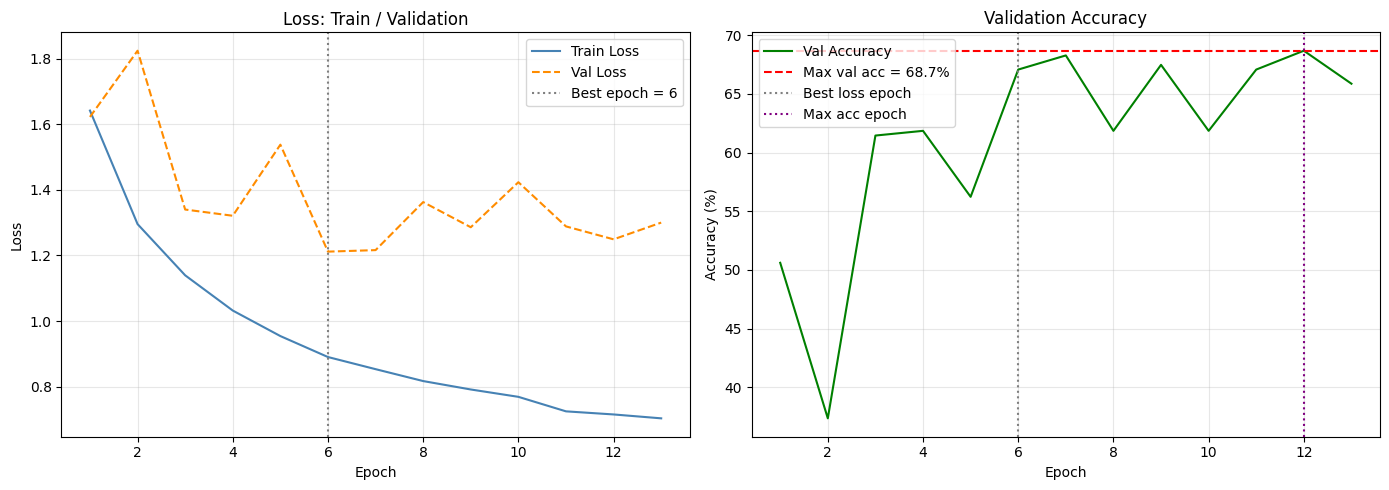

In [19]:

epochs_range = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

                                                                             
axes[0].plot(epochs_range, history['train_loss'], label='Train Loss', color='steelblue')
axes[0].plot(epochs_range, history['val_loss'], label='Val Loss', color='darkorange', linestyle='--')

if best_epoch > 0:
    axes[0].axvline(best_epoch, color='gray', linestyle=':', label=f'Best epoch = {best_epoch}')

axes[0].set_title('Loss: Train / Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

                                                                              
axes[1].plot(epochs_range, history['val_acc'], color='green', label='Val Accuracy')

                                                                 
                                                         
plot_max_val_acc = max(history['val_acc']) if history['val_acc'] else 0.0
plot_max_val_acc_epoch = history['val_acc'].index(plot_max_val_acc) + 1 if history['val_acc'] else 0
axes[1].axhline(
    y=plot_max_val_acc,
    color='red',
    linestyle='--',
    label=f'Max val acc = {plot_max_val_acc:.1f}%'
)

if best_epoch > 0:
    axes[1].axvline(best_epoch, color='gray', linestyle=':', label='Best loss epoch')
if plot_max_val_acc_epoch > 0:
    axes[1].axvline(plot_max_val_acc_epoch, color='purple', linestyle=':', label='Max acc epoch')

axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()



SUMMARY FINALE: ACCURACY ED ERROR
Train      | Loss: 0.6912 | Acc: 90.63% | Error: 9.37%
Validation | Loss: 1.2117 | Acc: 67.07% | Error: 32.93%
Test       | Loss: 1.3172 | Acc: 61.29% | Error: 38.71%
------------------------------------------------------------
Variance gap (Validation error - Training error): 23.57%
Test gap (Test error - Training error): 29.34%


RISULTATI FINALI SUL VALIDATION SET
Accuracy Generale: 67.07%
Error Rate: 32.93%
F1-Score (Macro): 0.6651


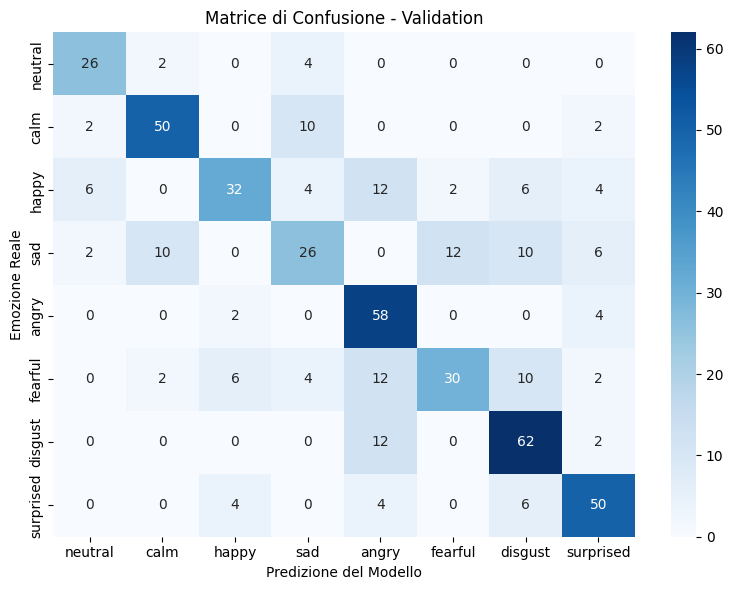



RISULTATI FINALI SUL TEST SET
Accuracy Generale: 61.29%
Error Rate: 38.71%
F1-Score (Macro): 0.6012


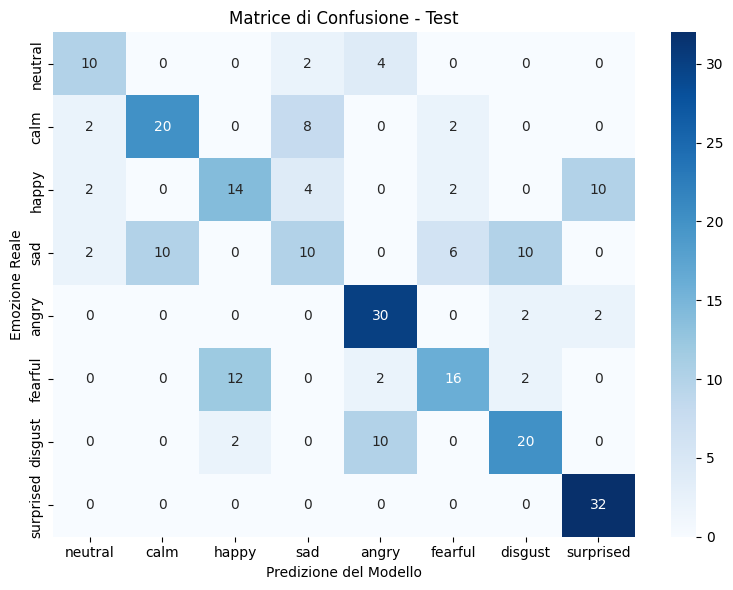



RISULTATI FINALI UTTERANCE-LEVEL SUL VALIDATION SET
Numero utterance valutate: 480
Accuracy Generale: 67.08%
Error Rate: 32.92%
F1-Score (Macro): 0.6657


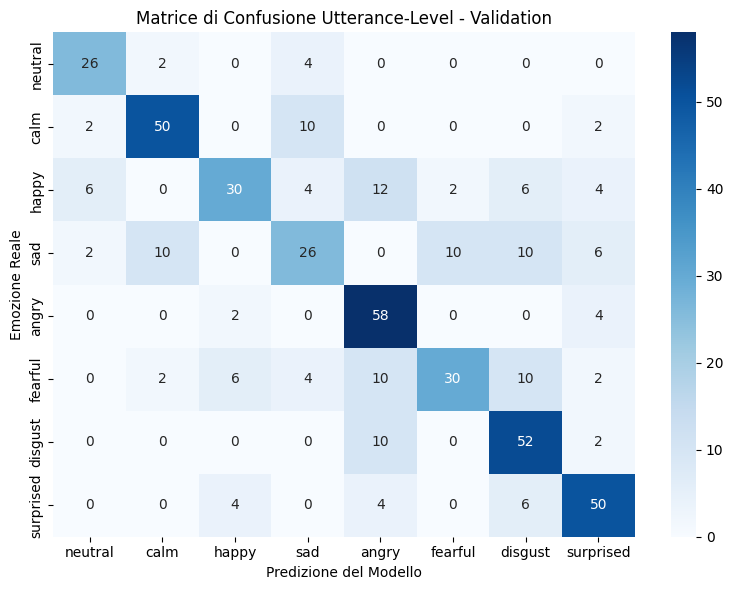



RISULTATI FINALI UTTERANCE-LEVEL SUL TEST SET
Numero utterance valutate: 240
Accuracy Generale: 61.67%
Error Rate: 38.33%
F1-Score (Macro): 0.6011


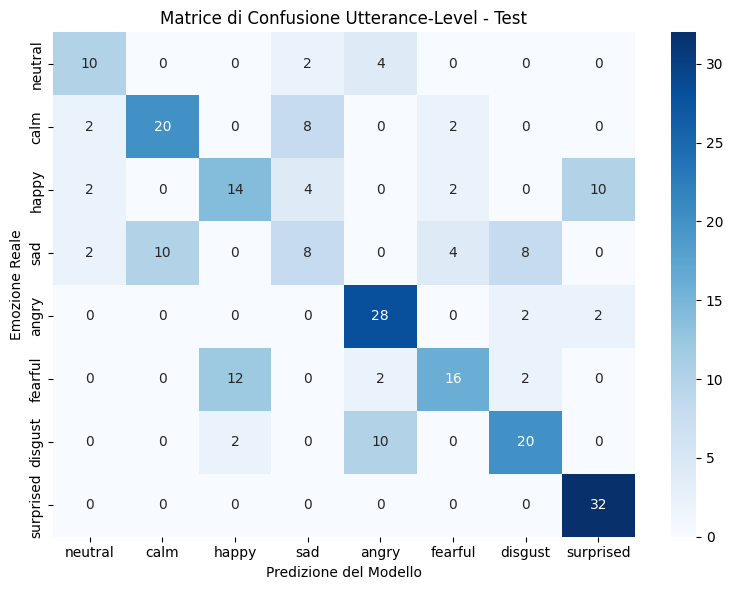

In [20]:
import os
                                                           
                                                                            
                                                                       
if 'BEST_MODEL_PATH' in globals() and os.path.exists(BEST_MODEL_PATH):
    model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
elif 'best_state' in globals() and best_state is not None:
    model.load_state_dict(best_state)
else:
    raise RuntimeError(
        "Best model non disponibile. Esegui prima la cella di training "
        "oppure salva il best model in BEST_MODEL_PATH."
    )

model.to(device)
model.eval()

classes = [emotion_map[i] for i in range(8)]

                                                    
                                                       
final_metrics = print_error_summary(
    model=model,
    criterion=criterion,
    device=device,
    transform=None
)


                                                                       
print()
val_acc_final, val_f1_final, val_cm = evaluate_model(
    model,
    val_loader,
    device,
    transform=None,
    classes=classes,
    split_name='Validation'
)

                                                                  
print()
test_acc_final, test_f1_final, test_cm = evaluate_model(
    model,
    test_loader,
    device,
    transform=None,
    classes=classes,
    split_name='Test'
)


                                                                           
                                                                    
                                                                                      
print()
val_utt_acc_final, val_utt_f1_final, val_utt_cm = evaluate_utterance_level(
    model,
    val_dataset,
    device,
    classes=classes,
    split_name='Validation'
)

print()
test_utt_acc_final, test_utt_f1_final, test_utt_cm = evaluate_utterance_level(
    model,
    test_dataset,
    device,
    classes=classes,
    split_name='Test'
)
